In [28]:
import pandas as pd 
import numpy as np


In [29]:
data=pd.read_csv("credit_card_dataset.csv")
data.head()

,Customer_ID,Age,Gender,Employment_Type,Annual_Income,Credit_Score,Loan_or_Credit_Amount,Number_of_Active_Accounts,Past_Default_Count,Application_Type,Region,Credit_Limit,Utilization_Ratio,Application_Date,Default_Status
0,1,59,Female,Self-Employed,1327923,519,1256914,7,4,Credit Card,South,391299.425625,1.0,2021-12-14,Yes
1,2,49,Male,Salaried,795537,598,489423,6,2,Home Loan,West,307767.155335,1.0,2022-03-18,No
2,3,35,Female,Salaried,696674,559,987992,11,2,Home Loan,East,236112.707145,1.0,2022-02-15,No
3,4,28,Female,Salaried,466265,593,1286291,9,3,Personal Loan,South,225519.016728,1.0,2021-02-10,No
4,5,41,Male,Salaried,731712,490,327335,3,0,Auto Loan,East,201288.628277,1.0,2022-12-21,No


In [30]:
data.columns

Index(['Customer_ID', 'Age', 'Gender', 'Employment_Type', 'Annual_Income',
       'Credit_Score', 'Loan_or_Credit_Amount', 'Number_of_Active_Accounts',
       'Past_Default_Count', 'Application_Type', 'Region', 'Credit_Limit',
       'Utilization_Ratio', 'Application_Date', 'Default_Status'],
      dtype='object')

In [31]:

data['Application_Date'] = pd.to_datetime(data['Application_Date'])

data.set_index('Application_Date', inplace=True)

In [32]:
print(data['Default_Status'].unique())
print(data['Default_Status'].dtype)

['Yes' 'No']
object


In [33]:
data['Default_Status'] = data['Default_Status'].map({
    'Yes': 1,
    'No': 0
})

In [34]:
monthly = data.resample('M').agg({
    'Default_Status': ['count', 'sum']
})

monthly.columns = ['total_applications', 'total_defaults']

monthly['default_rate'] = (
    monthly['total_defaults'] / monthly['total_applications']
)

print(monthly.head())

                  total_applications  total_defaults  default_rate
Application_Date                                                  
2021-01-31                       268              36      0.134328
2021-02-28                       252              34      0.134921
2021-03-31                       290              39      0.134483
2021-04-30                       254              31      0.122047
2021-05-31                       272              32      0.117647


C:\Users\OM\AppData\Local\Temp\ipykernel_16780\1140757088.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.resample('M').agg({


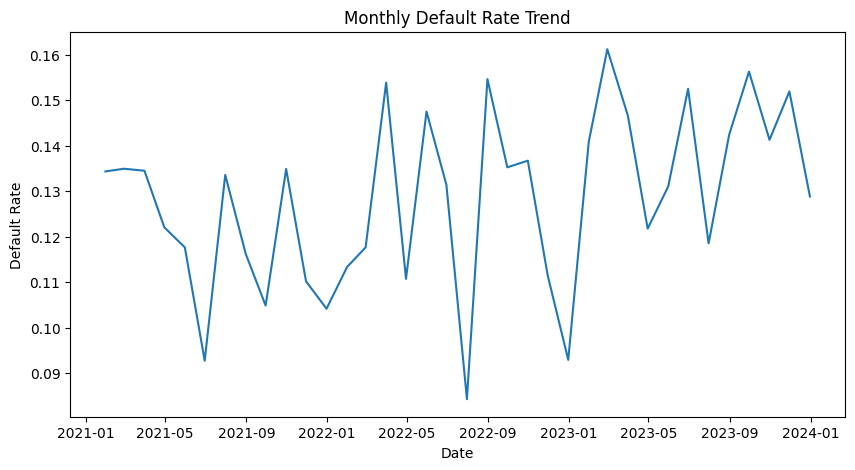

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly['default_rate'])
plt.title("Monthly Default Rate Trend")
plt.xlabel("Date")
plt.ylabel("Default Rate")
plt.show()